## Importar bibliotecas

In [310]:
import pandas as pd
import matplotlib.pyplot as plt

## Ler as bases de dados

In [311]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
geolocations = pd.read_csv("../data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
#order_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

## Verifica se os datasets foram criados   

In [312]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    #"order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
order_reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)


## Pergunta Norteadora
#### “Quais fatores mais influenciam a satisfação do cliente no e-commerce e como a empresa pode atuar sobre eles para melhorar a experiência?”

Para explorar a pergunta norteadora vamos investigar 5 variáveis:

- Dias de atraso na entrega: Vamos criar a variável [dias_atraso_entrega] =  max(0,[order_delivered_customer_date] - [order_estimated_delivery_date]), disponíveis em olist_orders_dataset
- Valor total da compra: que vai ser a soma dos itens comprados [preco_tota_item] = [price] + [freight_value]obs. Optamos por não utilizar o valor total da compra para manter a granularidade da tabela no nível de item
- Valor do frete: [frete_total] = order_items.groupby("order_id")["freight_value"].sum() disponível na olist_order_items_dataset
- Região (Cidade e Estado)

Pretendemos descobrir o impacto que essas variáveis possuem na dimenssão experiência:

- Experiência do cliente: Vamos considerar com base na avaliação [review_score], disponível na base olist_order_reviews_dataset


No final da análise pretendemos avaliar o impacto que as 4 variáveis explicativas possuem na variável resultado, com isso imaginar soluções e fatores operacionais que devem ser priorizados pelos vendedores para maximizar a satisfação dos clientes.


### Preparação dos dados

A Base desejada tem o formato:

        "order_id",
        "order_item_id",
        "product_id",
        "customer_id" - olist_customers_dataset
        "seller_id",
        "product_category_name",
        "dias_atraso_entrega",
        "preco_total_item",
        "price",
        "freight_value",
        "review_score",
        "customer_city" - olist_customers_dataset
        "customer_state" - olist_customers_dataset

        

Onde um mesmo order_id terá n linhas dependendo da quantidade de itens

## Preparação dos dados (ETL)

In [313]:
# Filtrar a base orders para apenas pedidos com status 'delivered'
orders = orders[orders["order_status"] == "delivered"]

# Verificar as primeiras linhas
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,96478,96478,96478,96478,96464,96476,96470,96478
unique,96478,96478,1,95956,88274,80106,95658,445
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,507


In [314]:
# Criando a variável dias_atraso_entrega no df orders

# Tranformando as colunas de data para o formato datetime

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

# Criando a variável dias_atraso_entrega

orders["dias_atraso_entrega"] = (
    # Variável de atraso de entrega é a diferença entre a data de entrega real e a data de entrega estimada
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

# Atraso não pode ser negativo, então usamos clip para definir o valor mínimo como 0
orders["dias_atraso_entrega"] = orders["dias_atraso_entrega"].clip(lower=0) 


In [315]:
# ...existing code...

# Agrupar order_items por order_id e somar price e freight_value
order_totals = order_items.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "sum"
}).reset_index()

# Renomear as colunas para clareza
order_totals.rename(columns={
    "price": "total_preco",
    "freight_value": "total_frete"
}, inplace=True)

# Mesclar os totais de volta na base orders
df = orders.merge(order_totals, on="order_id", how="left")

# Verificar as primeiras linhas para confirmar


df[df["order_id"] == "8272b63d03f5f79c56e9e4120aec44ef"]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dias_atraso_entrega,total_preco,total_frete
86192,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28,3.0,31.8,164.37


In [316]:
# Testando se existem valores duplicados no campo order_id da tabela de avaliações

order_reviews["order_id"].duplicated().sum()

# O resultado positivo indica que existem avaliações duplicadas para um mesmo pedido, portanto precisamos tratar essas avaliações para evitar distorções nas análises.


np.int64(551)

In [317]:
# Adicionando as avaliações dos pedidos ao df

# Mantem apenas a última avaliação para cada pedido, caso haja mais de uma avaliação para um mesmo pedido. Isso é feito usando o método drop_duplicates com o parâmetro keep='last'.
reviews_unique = order_reviews.drop_duplicates(subset="order_id", keep='last').reset_index(drop=True)

# Adicionando a média das avaliações por pedido ao df

df = df.merge(
    reviews_unique[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [318]:
# buscando o customer_unique_id para identificar os clientes únicos e suas respectivas cidades e estados

df = df.merge(
    customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]],
    on="customer_id",
    how="left"
)

In [319]:
# Converter order_purchase_timestamp para datetime
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Adicionar colunas de data e hora
df["ano_compra"] = df["order_purchase_timestamp"].dt.year
df["data_compra"] = df["order_purchase_timestamp"].dt.date

# Verificar resultado
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dias_atraso_entrega,total_preco,total_frete,review_score,customer_unique_id,customer_city,customer_state,ano_compra,data_compra
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.0,29.99,8.72,4.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0.0,118.70,22.76,4.0,af07308b275d755c9edb36a90c618231,barreiras,BA,2018,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.0,159.90,19.22,5.0,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,2018,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.0,45.00,27.20,5.0,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,2017,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0.0,19.90,8.72,5.0,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,2018,2018-02-13


In [320]:
# Selecionando colunas relevantes para análise

df_final = df[
    [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "order_purchase_timestamp",
        "ano_compra",
        "data_compra",
        "review_score",
        "customer_city",
        "customer_state",
        "dias_atraso_entrega",
        "total_preco",
        "total_frete",
    ]
]

In [321]:
# Apresentando as primeiras linhas do df_final para verificar se os dados foram integrados corretamente

df_final.head()

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,ano_compra,data_compra,review_score,customer_city,customer_state,dias_atraso_entrega,total_preco,total_frete
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017,2017-10-02,4.0,sao paulo,SP,0.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018,2018-07-24,4.0,barreiras,BA,0.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018,2018-08-08,5.0,vianopolis,GO,0.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017,2017-11-18,5.0,sao goncalo do amarante,RN,0.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018,2018-02-13,5.0,santo andre,SP,0.0,19.90,8.72


___________________________

### Entendendo a variável de resultado

In [322]:
df_final["review_score"].value_counts(normalize=True)

review_score
5.0    0.592255
4.0    0.197147
1.0    0.097567
3.0    0.082572
2.0    0.030460
Name: proportion, dtype: float64

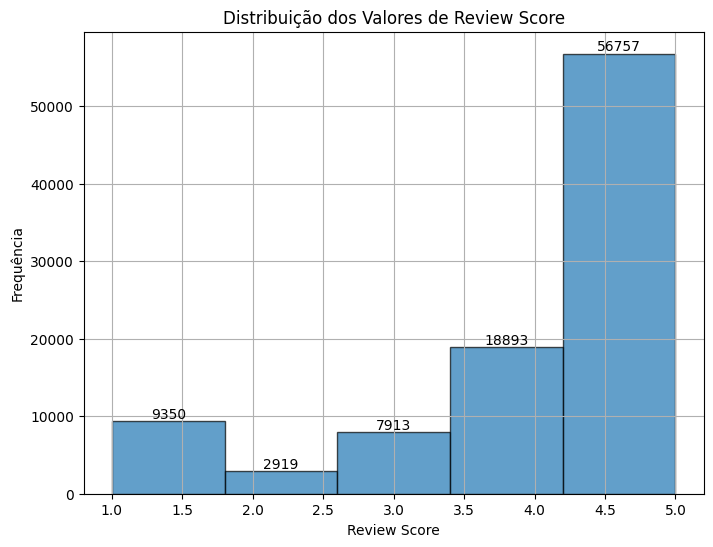

In [323]:
# Histograma da distribuição dos valores de review_score

plt.figure(figsize=(8, 6))

counts, bins, patches = plt.hist(
    df_final['review_score'].dropna(),
    bins=5,
    edgecolor='black',
    alpha=0.7
)

# Adiciona rótulos de frequência em cada barra
plt.bar_label(patches, fmt='%.0f')

plt.title('Distribuição dos Valores de Review Score')
plt.xlabel('Review Score')
plt.ylabel('Frequência')
plt.grid(True)

plt.show()

## Começando as análises

### Dias de atraso na entrega

In [ ]:
# Retira atrasos maiores que 30 dias para evitar distorção na análise de avaliação por atraso
df_atraso_filtrado = df_final[
    df_final["dias_atraso_entrega"] <= 30
]

# Calcula a avaliação média por dias de atraso
atraso_vs_review = (
    df_atraso_filtrado
    .groupby("dias_atraso_entrega")["review_score"]
    .mean()
    .reset_index()
)

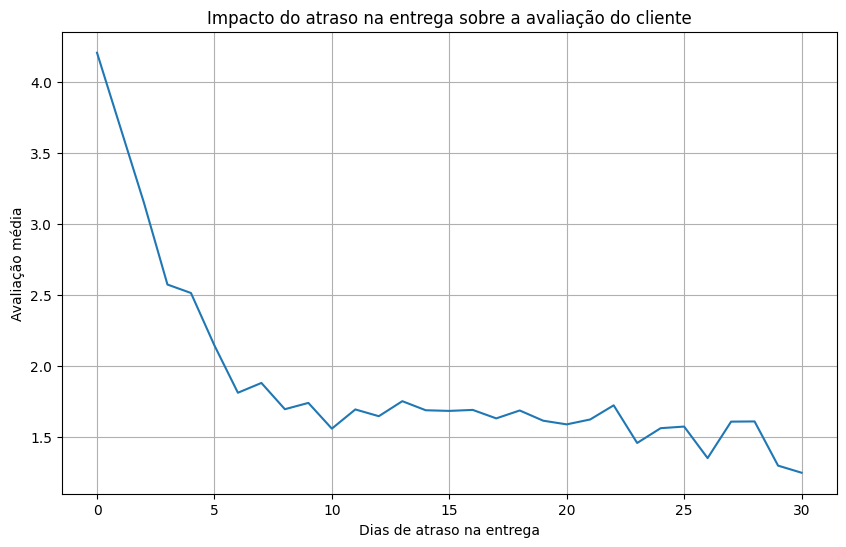

In [ ]:
# Gráfico de linha da avaliação média por dias de atraso

plt.figure(figsize=(10,6))

plt.plot(
    atraso_vs_review["dias_atraso_entrega"],
    atraso_vs_review["review_score"]
)

plt.xlabel("Dias de atraso na entrega")
plt.ylabel("Avaliação média")
plt.title("Impacto do atraso na entrega sobre a avaliação do cliente")
plt.grid(True)

plt.show()

In [ ]:
# R² para avaliar a relação entre dias de atraso e avaliação

from sklearn.linear_model import LinearRegression

X = atraso_vs_review[["dias_atraso_entrega"]]
y = atraso_vs_review["review_score"]

modelo = LinearRegression()
modelo.fit(X, y)

r2 = modelo.score(X, y)
r2

0.5395106483238816

In [ ]:
# Comparação da avaliação média para entregas no prazo vs entregas com atraso

print("Avaliação média para entregas no prazo:", df_final[df_final["dias_atraso_entrega"] == 0]["review_score"].mean())
print("Avaliação média para entregas com atraso:", df_final[df_final["dias_atraso_entrega"] > 0]["review_score"].mean())


Avaliação média para entregas no prazo: 4.207772400645256
Avaliação média para entregas com atraso: 2.257622811970638


A análise da relação entre o atraso na entrega e a avaliação média dos pedidos evidenciou uma forte correlação negativa. Observou-se que mesmo pequenos atrasos de 2 a 3 dias resultam em quedas expressivas na avaliação média, que passa de valores superiores a 4 para níveis próximos a 2. Após aproximadamente uma semana de atraso, a avaliação se estabiliza em patamares baixos, indicando que o cliente já percebeu a experiência como insatisfatória.

### Valor total da compra

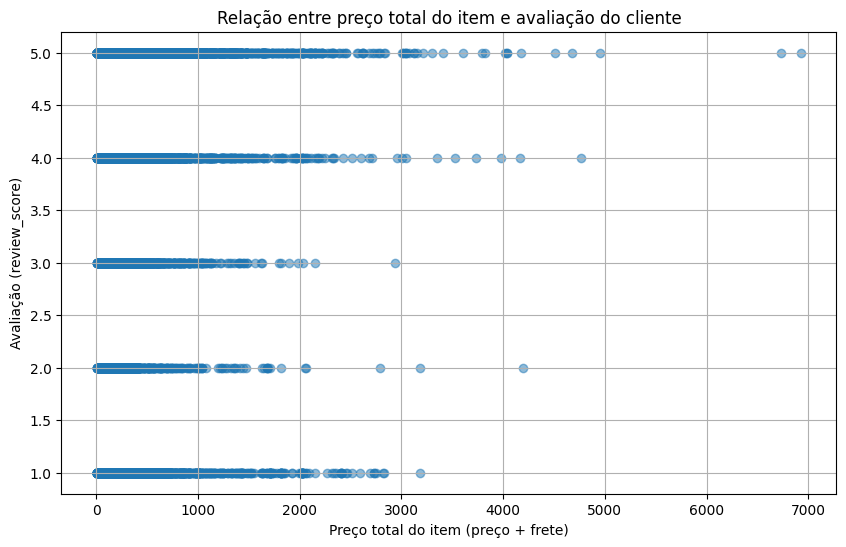

In [ ]:
# Gráfico de dispensção das avaliações vs o valor total do item (preço + frete)

plt.figure(figsize=(10,6))
plt.scatter(df_final["preco_total_item"], df_final["review_score"], alpha=0.5)
plt.xlabel("Preço total do item (preço + frete)")
plt.ylabel("Avaliação (review_score)")
plt.title("Relação entre preço total do item e avaliação do cliente")
plt.grid(True)
plt.show()


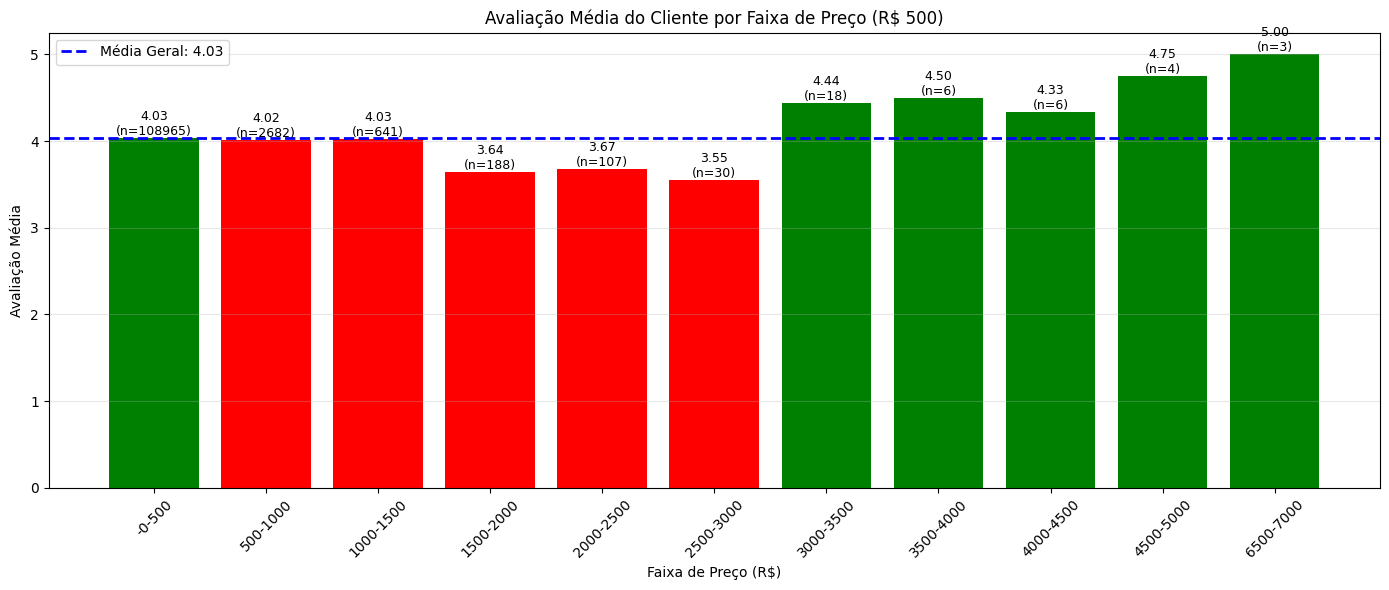

In [ ]:
# Histograma de 500 em 500 reais com avaliação média no eixo y

# Criando bins de 500 em 500 reais
bins = list(range(0, int(df_final["preco_total_item"].max()) + 500, 500))

# Criando uma coluna com o bin de preço
df_final["faixa_preco"] = pd.cut(df_final["preco_total_item"], bins=bins, include_lowest=True)

# Agrupando por faixa de preço e calculando a média das avaliações e total de compras
avaliacao_por_faixa = (
    df_final
    .groupby("faixa_preco", observed=True)
    .agg({
        "review_score": "mean",
        "order_id": "count"
    })
    .rename(columns={"order_id": "total_compras"})
    .reset_index()
)

# Calculando a avaliação média geral
media_geral = df_final["review_score"].mean()

# Definindo cores: verde se acima da média, vermelho se abaixo
cores = ['green' if avaliacao >= media_geral else 'red' for avaliacao in avaliacao_por_faixa["review_score"]]

# Gráfico de barras
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(avaliacao_por_faixa)), avaliacao_por_faixa["review_score"], color=cores)

# Adicionando rótulos com avaliação média e total de compras
for i, (bar, avg, count) in enumerate(zip(bars, avaliacao_por_faixa["review_score"], avaliacao_por_faixa["total_compras"])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{avg:.2f}\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.axhline(media_geral, color='blue', linestyle='--', linewidth=2, label=f'Média Geral: {media_geral:.2f}')
plt.xlabel("Faixa de Preço (R$)")
plt.ylabel("Avaliação Média")
plt.title("Avaliação Média do Cliente por Faixa de Preço (R$ 500)")
plt.xticks(range(len(avaliacao_por_faixa)), [f"{interval.left:.0f}-{interval.right:.0f}" for interval in avaliacao_por_faixa["faixa_preco"]], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Removendo a coluna temporária
df_final = df_final.drop("faixa_preco", axis=1)

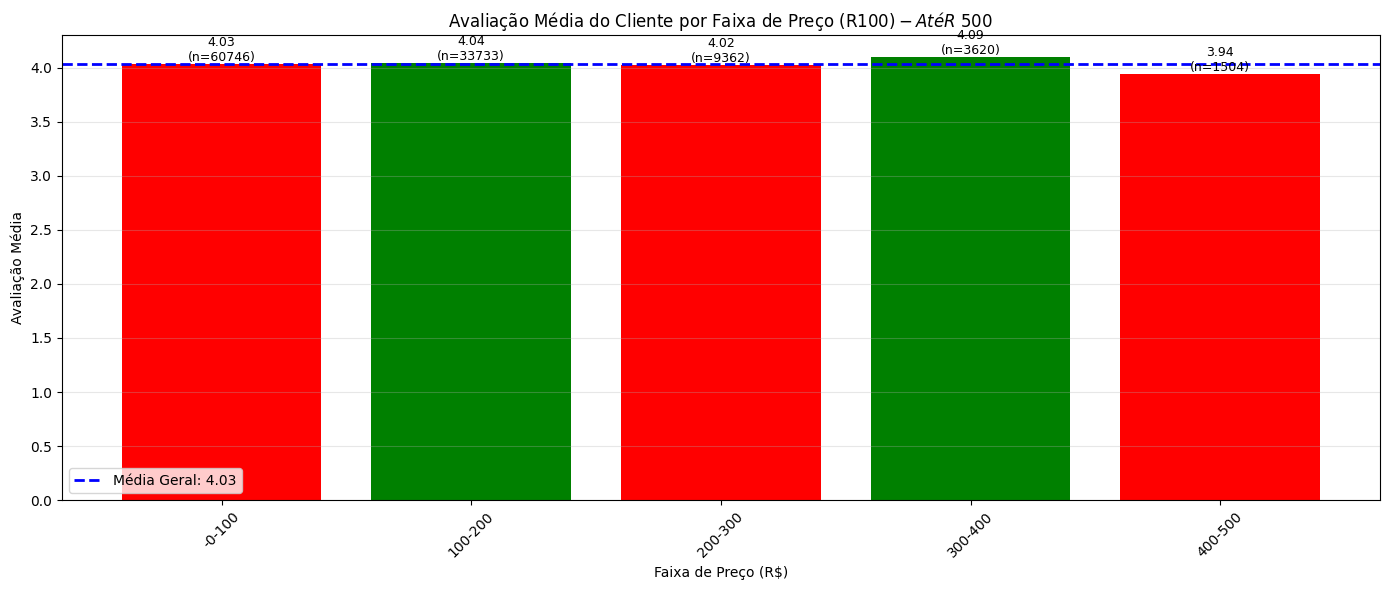

In [ ]:
# Mesmo gráfico anterior, mas apenas com pedidos de até 500 reais e bins de 100 em 100

# Filtrando dados até 500 reais
df_filtrado = df_final[df_final["preco_total_item"] <= 500]

# Criando bins de 100 em 100 reais
bins = list(range(0, 501, 100))

# Criando uma coluna com o bin de preço
df_filtrado["faixa_preco"] = pd.cut(df_filtrado["preco_total_item"], bins=bins, include_lowest=True)

# Agrupando por faixa de preço e calculando a média das avaliações e total de compras
avaliacao_por_faixa_filtrado = (
    df_filtrado
    .groupby("faixa_preco", observed=True)
    .agg({
        "review_score": "mean",
        "order_id": "count"
    })
    .rename(columns={"order_id": "total_compras"})
    .reset_index()
)

# Calculando a avaliação média geral
media_geral = df_final["review_score"].mean()

# Definindo cores: verde se acima da média, vermelho se abaixo
cores = ['green' if avaliacao >= media_geral else 'red' for avaliacao in avaliacao_por_faixa_filtrado["review_score"]]

# Gráfico de barras
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(avaliacao_por_faixa_filtrado)), avaliacao_por_faixa_filtrado["review_score"], color=cores)

# Adicionando rótulos com avaliação média e total de compras
for i, (bar, avg, count) in enumerate(zip(bars, avaliacao_por_faixa_filtrado["review_score"], avaliacao_por_faixa_filtrado["total_compras"])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{avg:.2f}\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.axhline(media_geral, color='blue', linestyle='--', linewidth=2, label=f'Média Geral: {media_geral:.2f}')
plt.xlabel("Faixa de Preço (R$)")
plt.ylabel("Avaliação Média")
plt.title("Avaliação Média do Cliente por Faixa de Preço (R$ 100) - Até R$ 500")
plt.xticks(range(len(avaliacao_por_faixa_filtrado)), [f"{interval.left:.0f}-{interval.right:.0f}" for interval in avaliacao_por_faixa_filtrado["faixa_preco"]], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Removendo a coluna temporária
df_filtrado = df_filtrado.drop("faixa_preco", axis=1)

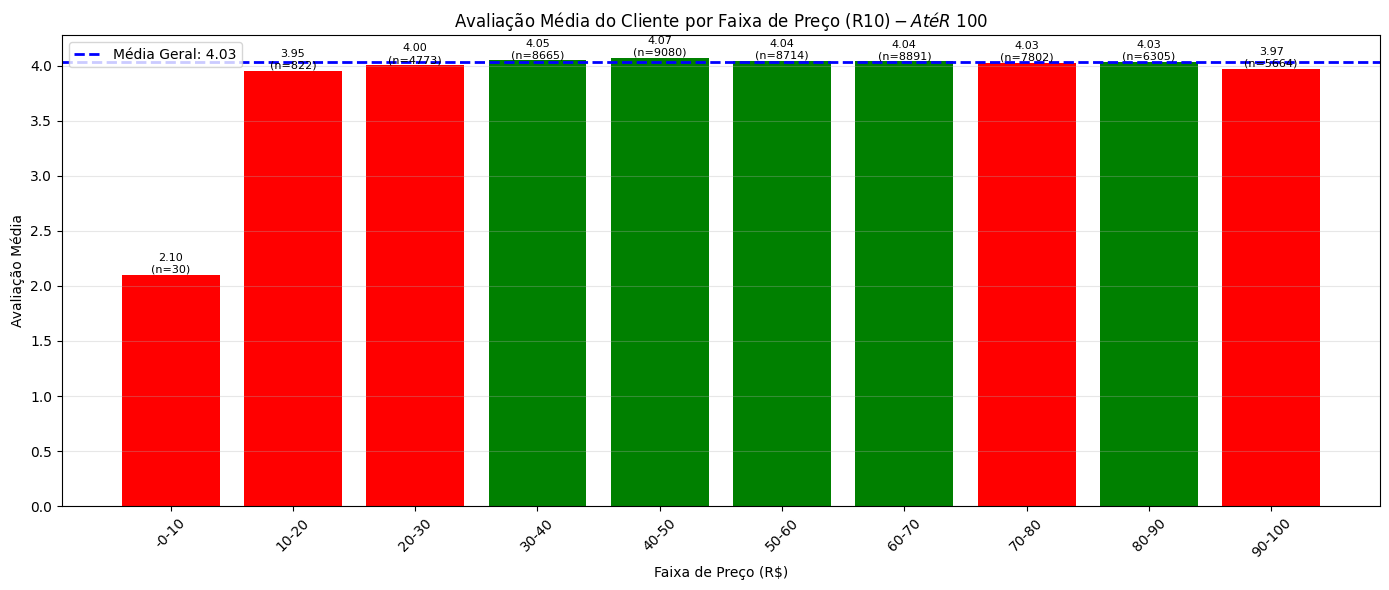

In [ ]:
# Gráfico com compras até 100 reais e bins de 10 em 10

# Filtrando dados até 100 reais
df_filtrado_100 = df_final[df_final["preco_total_item"] <= 100]

# Criando bins de 10 em 10 reais
bins_10 = list(range(0, 101, 10))

# Criando uma coluna com o bin de preço
df_filtrado_100["faixa_preco"] = pd.cut(df_filtrado_100["preco_total_item"], bins=bins_10, include_lowest=True)

# Agrupando por faixa de preço e calculando a média das avaliações e total de compras
avaliacao_por_faixa_100 = (
    df_filtrado_100
    .groupby("faixa_preco", observed=True)
    .agg({
        "review_score": "mean",
        "order_id": "count"
    })
    .rename(columns={"order_id": "total_compras"})
    .reset_index()
)

# Calculando a avaliação média geral
media_geral = df_final["review_score"].mean()

# Definindo cores: verde se acima da média, vermelho se abaixo
cores = ['green' if avaliacao >= media_geral else 'red' for avaliacao in avaliacao_por_faixa_100["review_score"]]

# Gráfico de barras
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(avaliacao_por_faixa_100)), avaliacao_por_faixa_100["review_score"], color=cores)

# Adicionando rótulos com avaliação média e total de compras
for i, (bar, avg, count) in enumerate(zip(bars, avaliacao_por_faixa_100["review_score"], avaliacao_por_faixa_100["total_compras"])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{avg:.2f}\n(n={count})', ha='center', va='bottom', fontsize=8)

plt.axhline(media_geral, color='blue', linestyle='--', linewidth=2, label=f'Média Geral: {media_geral:.2f}')
plt.xlabel("Faixa de Preço (R$)")
plt.ylabel("Avaliação Média")
plt.title("Avaliação Média do Cliente por Faixa de Preço (R$ 10) - Até R$ 100")
plt.xticks(range(len(avaliacao_por_faixa_100)), [f"{interval.left:.0f}-{interval.right:.0f}" for interval in avaliacao_por_faixa_100["faixa_preco"]], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Removendo a coluna temporária
df_filtrado_100 = df_filtrado_100.drop("faixa_preco", axis=1)

### Valor do frete

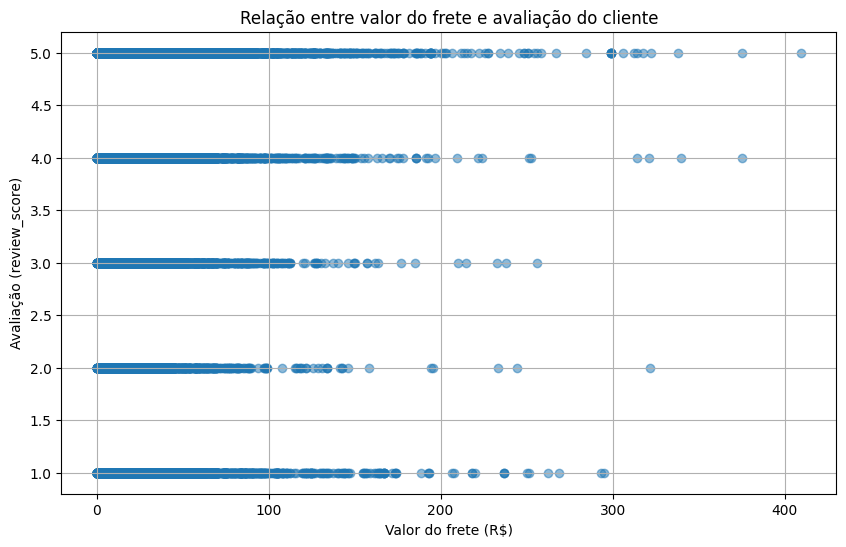

In [ ]:
# Grafico de dispersão do valor do frete vs avaliação

plt.figure(figsize=(10,6))
plt.scatter(df_final["freight_value"], df_final["review_score"], alpha=0.5)
plt.xlabel("Valor do frete (R$)")
plt.ylabel("Avaliação (review_score)")
plt.title("Relação entre valor do frete e avaliação do cliente")
plt.grid(True)
plt.show()


### Região (Cidade e Estado)

## Análise final

### Analisando se total de vendas do vendedor pode ser impactado pela avaliação média

In [ ]:
resumo_vendedores = (
    df_final
    .groupby("seller_id")
    .agg({
        "order_id": "nunique",      # total de vendas (pedidos)
        "review_score": "mean"      # média de avaliação
    })
    .rename(columns={
        "order_id": "total_vendas",
        "review_score": "avaliacao_media"
    })
    .sort_values("total_vendas", ascending=False)
)

resumo_vendedores.head(10)

,total_vendas,avaliacao_media
seller_id,,
6560211a19b47992c3666cc44a7e94c0,1854,3.907646
4a3ca9315b744ce9f8e9374361493884,1806,3.800204
cc419e0650a3c5ba77189a1882b7556a,1706,4.069044
1f50f920176fa81dab994f9023523100,1404,3.988560
da8622b14eb17ae2831f4ac5b9dab84a,1314,4.059547
955fee9216a65b617aa5c0531780ce60,1287,4.050437
7a67c85e85bb2ce8582c35f2203ad736,1160,4.233219
ea8482cd71df3c1969d7b9473ff13abc,1146,3.952341
4869f7a5dfa277a7dca6462dcf3b52b2,1132,4.122822


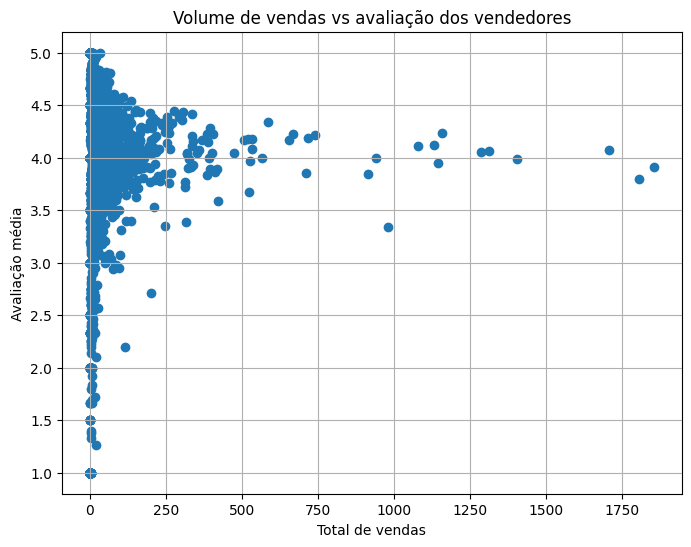

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    resumo_vendedores["total_vendas"],
    resumo_vendedores["avaliacao_media"]
)

plt.xlabel("Total de vendas")
plt.ylabel("Avaliação média")
plt.title("Volume de vendas vs avaliação dos vendedores")
plt.grid(True)
plt.show()

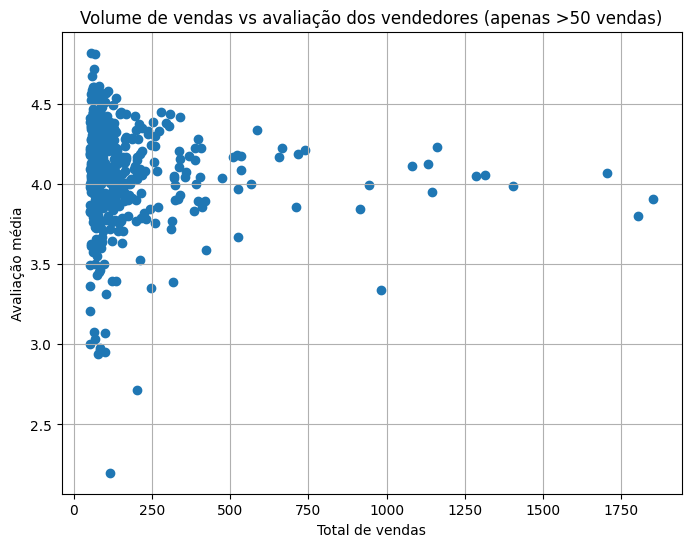

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    resumo_vendedores[resumo_vendedores["total_vendas"] > 50]["total_vendas"],
    resumo_vendedores[resumo_vendedores["total_vendas"] > 50]["avaliacao_media"]
)

plt.xlabel("Total de vendas")
plt.ylabel("Avaliação média")
plt.title("Volume de vendas vs avaliação dos vendedores (apenas >50 vendas)")
plt.grid(True)

plt.show()

In [ ]:
pedidos_atrasados = (
    df_final[df_final["dias_atraso_entrega"] > 0]["order_id"]
    .nunique()
)

pedidos_atrasados


6535